In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

from torchvision import transforms, models
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc

import timm
from tqdm import tqdm

In [3]:
DATA_DIR = "Driver Drowsiness Dataset"
OUT_DIR = "models/"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 2
IMAGE_SIZE = 227
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

CLASS_NAMES = sorted([p.name for p in Path(DATA_DIR).iterdir() if p.is_dir()])
print(CLASS_NAMES)

['Drowsy', 'Non Drowsy']


In [4]:
class Dataset(Dataset):
    def __init__(self, root, classes, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.samples = []
        self.class_to_idx = {c:i for i,c in enumerate(classes)}

        for c in classes:
            for p in (self.root/c).glob("*"):
                if p.suffix.lower() in [".png",".jpg",".jpeg",".tiff",".bmp"]:
                    self.samples.append((str(p), self.class_to_idx[c]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p, lbl = self.samples[idx]
        img = Image.open(p).convert("RGB")
        if self.transform: 
            img = self.transform(img)
        return img, lbl

In [5]:
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])


In [6]:
dataset = Dataset(DATA_DIR, CLASS_NAMES, transform=train_tf)

n = len(dataset)
val_size = int(0.30*n)
train_size = n - val_size 

In [7]:
train_set, val_set = random_split(
    dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_set.dataset.transform = train_tf
val_set.dataset.transform = eval_tf

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
def train_model(model, optimizer, scheduler, model_name):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_acc = 0

    for epoch in range(EPOCHS):
        model.train()
        train_preds, train_true = [], []

        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # --- Collect train accuracy ---
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_true.extend(labels.cpu().numpy())

        # ---- Compute Train Accuracy ----
        train_acc = accuracy_score(train_true, train_preds)

        # ---- Validation ----
        model.eval()
        val_preds, val_true = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                preds = torch.argmax(outputs, dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_true, val_preds)

        if scheduler:
            scheduler.step()

        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

In [9]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 5))
    precision.append(round(b, 5))
    recall.append(round(c, 5))
    f1score.append(round(d, 5))

# VGG19

In [10]:
model = timm.create_model("vgg19_bn", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [11]:
train_model(model, optimizer, scheduler, "VGG19")

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [05:16<00:00,  2.89it/s]


Epoch 1/10 | Train Acc: 0.9966 | Val Acc: 0.9937


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:32<00:00,  4.32it/s]


Epoch 2/10 | Train Acc: 0.9985 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:30<00:00,  4.34it/s]


...

Epoch 8/10 | Train Acc: 1.0000 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:33<00:00,  4.29it/s]


Epoch 9/10 | Train Acc: 1.0000 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:30<00:00,  4.35it/s]


Epoch 10/10 | Train Acc: 1.0000 | Val Acc: 0.9999


In [12]:
torch.save(model.state_dict(), os.path.join(OUT_DIR, "vgg19_final.pth"))

In [13]:
model.eval()
all_probs = []; all_preds = []; all_labels = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="VGG19 test"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.append(probs); all_preds.append(preds); all_labels.append(labels.numpy())
y_probs = np.vstack(all_probs); y_pred = np.concatenate(all_preds); y_true = np.concatenate(all_labels)
vgg_acc = accuracy_score(y_true, y_pred)
vgg_prec, vgg_rec, vgg_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

VGG19 test: 100%|█████████████████████████████████████████████████████████████████████████████████| 392/392 [00:55<00:00,  7.10it/s]


In [14]:
storeResults('VGG19',vgg_acc,vgg_prec,vgg_rec,vgg_f1)

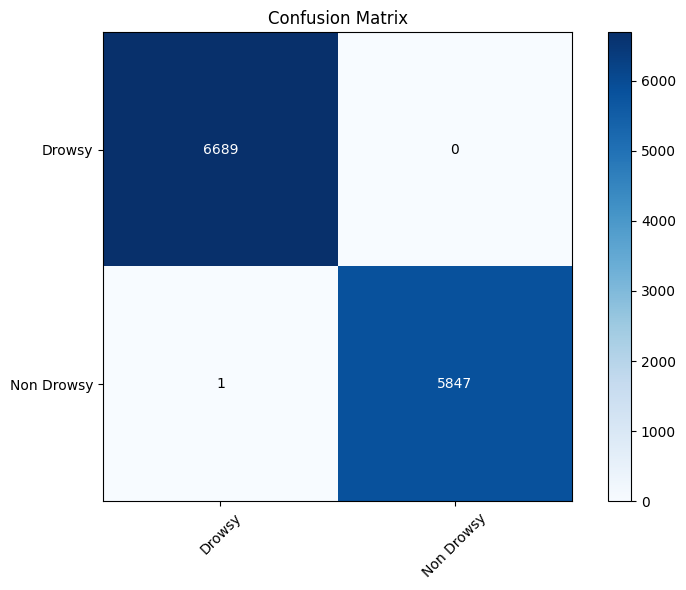

In [15]:
unique_classes = sorted(list(np.unique(y_true)))
class_labels = [CLASS_NAMES[c] for c in unique_classes]

cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(unique_classes, class_labels, rotation=45)
plt.yticks(unique_classes, class_labels)

for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

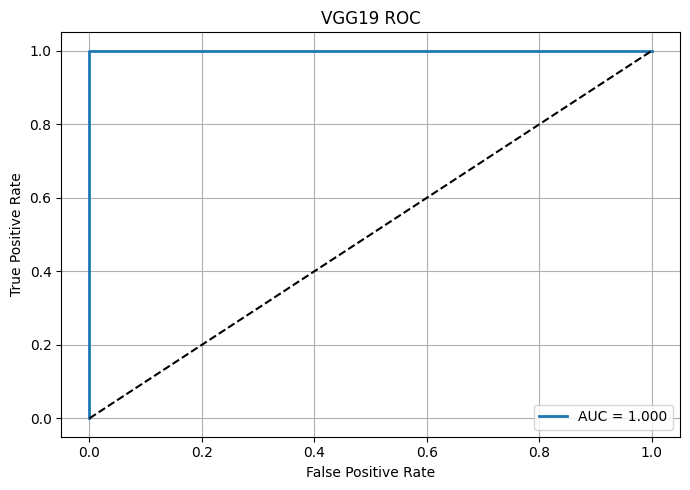

In [16]:
# Ensure binary
assert len(np.unique(y_true)) == 2, "Binary ROC requires exactly 2 classes"

# Extract probabilities for the positive class (class 1)
y_scores = y_probs[:, 1]

# Compute ROC components
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG19 ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# VGG 16

In [17]:
model = timm.create_model("vgg16_bn", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/554M [00:00<?, ?B/s]

In [18]:
train_model(model, optimizer, scheduler, "VGG16")

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:17<00:00,  4.63it/s]


Epoch 1/10 | Train Acc: 0.9974 | Val Acc: 0.9375


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:17<00:00,  4.63it/s]


Epoch 2/10 | Train Acc: 0.9990 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:17<00:00,  4.64it/s]


...

Epoch 8/10 | Train Acc: 0.9999 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:18<00:00,  4.61it/s]


Epoch 9/10 | Train Acc: 1.0000 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [03:17<00:00,  4.64it/s]


Epoch 10/10 | Train Acc: 1.0000 | Val Acc: 1.0000


In [19]:
torch.save(model.state_dict(), os.path.join(OUT_DIR, "vgg16_final.pth"))

In [20]:
model.eval()
all_probs = []; all_preds = []; all_labels = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="VGG16 test"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.append(probs); all_preds.append(preds); all_labels.append(labels.numpy())
y_probs = np.vstack(all_probs); y_pred = np.concatenate(all_preds); y_true = np.concatenate(all_labels)
vgg_acc = accuracy_score(y_true, y_pred)
vgg_prec, vgg_rec, vgg_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

VGG16 test: 100%|█████████████████████████████████████████████████████████████████████████████████| 392/392 [00:54<00:00,  7.16it/s]


In [21]:
storeResults('VGG16',vgg_acc,vgg_prec,vgg_rec,vgg_f1)

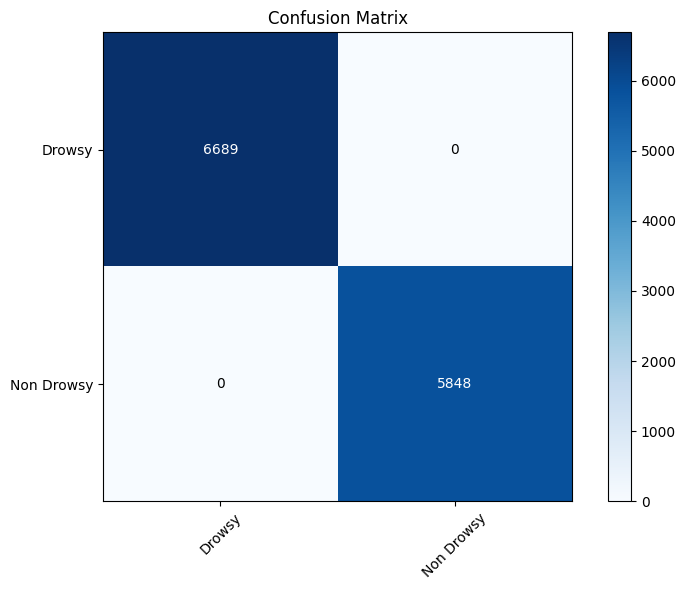

In [22]:
unique_classes = sorted(list(np.unique(y_true)))
class_labels = [CLASS_NAMES[c] for c in unique_classes]

cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(unique_classes, class_labels, rotation=45)
plt.yticks(unique_classes, class_labels)

for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

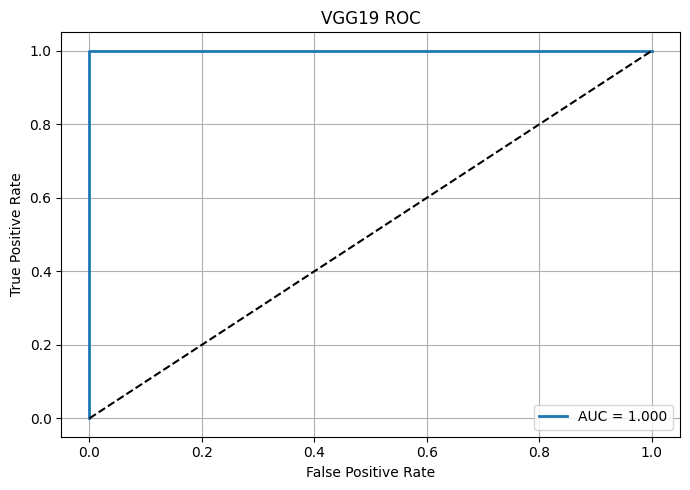

In [23]:
# Ensure binary
assert len(np.unique(y_true)) == 2, "Binary ROC requires exactly 2 classes"

# Extract probabilities for the positive class (class 1)
y_scores = y_probs[:, 1]

# Compute ROC components
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG19 ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# InceptionV3

In [24]:

model = timm.create_model("inception_v3", pretrained=True, num_classes=NUM_CLASSES, aux_logits=False)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)





In [25]:

train_model(model, optimizer, scheduler, "InceptionV3")


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:33<00:00,  5.96it/s]


Epoch 1/10 | Train Acc: 0.9943 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:33<00:00,  5.94it/s]


Epoch 2/10 | Train Acc: 1.0000 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:26<00:00,  6.23it/s]


...

Epoch 8/10 | Train Acc: 1.0000 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:31<00:00,  6.02it/s]


Epoch 9/10 | Train Acc: 1.0000 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:31<00:00,  6.02it/s]


Epoch 10/10 | Train Acc: 1.0000 | Val Acc: 1.0000


In [26]:

torch.save(model.state_dict(), os.path.join(OUT_DIR, "inceptionv3_final.pth"))



In [27]:

model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="InceptionV3 test"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_probs = np.vstack(all_probs)
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)


inception_acc = accuracy_score(y_true, y_pred)
inception_prec, inception_rec, inception_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)


InceptionV3 test: 100%|███████████████████████████████████████████████████████████████████████████| 392/392 [01:16<00:00,  5.10it/s]


In [28]:
storeResults('InceptionV3', inception_acc, inception_prec, inception_rec, inception_f1)



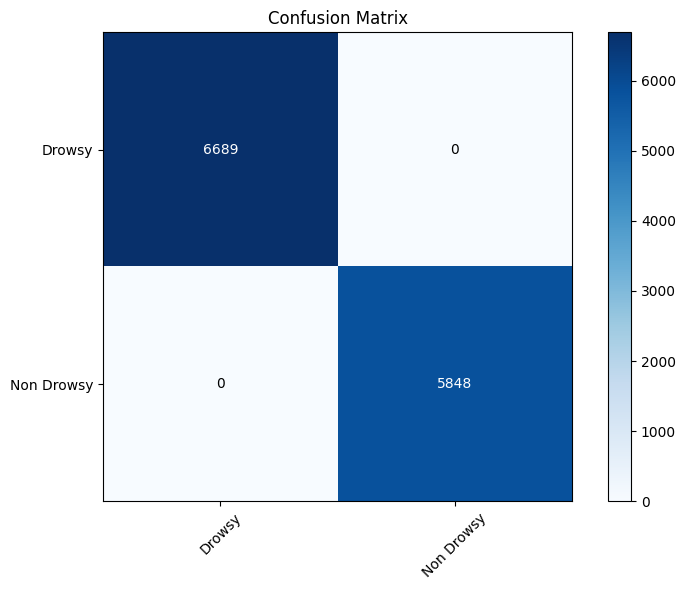

In [29]:

cm = confusion_matrix(y_true, y_pred, labels=unique_classes)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(unique_classes, class_labels, rotation=45)
plt.yticks(unique_classes, class_labels)
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center', 
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

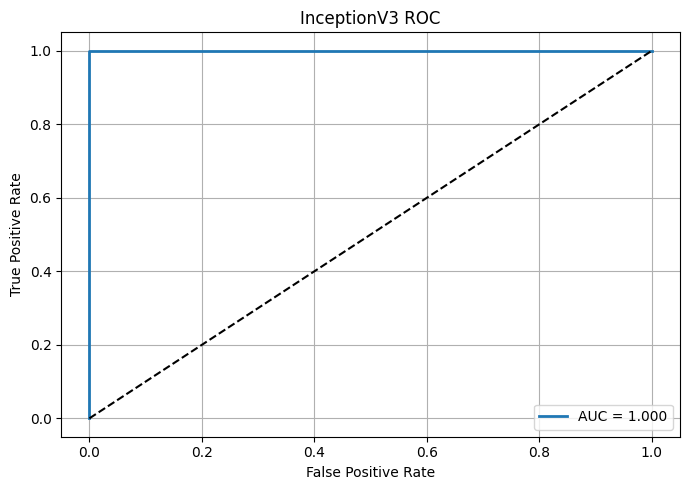

In [30]:


y_scores = y_probs[:, 1] 

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("InceptionV3 ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Resnet 50

In [31]:

model = timm.create_model("resnetv2_50x1_bitm", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)



Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [32]:

train_model(model, optimizer, scheduler, "ResNet50")


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:17<00:00,  6.67it/s]


Epoch 1/10 | Train Acc: 0.9835 | Val Acc: 0.9972


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:17<00:00,  6.66it/s]


Epoch 2/10 | Train Acc: 0.9971 | Val Acc: 0.9840


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:17<00:00,  6.66it/s]


...

Epoch 8/10 | Train Acc: 1.0000 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:16<00:00,  6.70it/s]


Epoch 9/10 | Train Acc: 1.0000 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:16<00:00,  6.72it/s]


Epoch 10/10 | Train Acc: 1.0000 | Val Acc: 0.9999


In [33]:

torch.save(model.state_dict(), os.path.join(OUT_DIR, "resnet50_final.pth"))



In [34]:
# --- Evaluation ---
model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="ResNet50 test"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_probs = np.vstack(all_probs)
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# --- Metrics ---
resnet_acc = accuracy_score(y_true, y_pred)
resnet_prec, resnet_rec, resnet_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)



ResNet50 test: 100%|██████████████████████████████████████████████████████████████████████████████| 392/392 [00:53<00:00,  7.39it/s]


In [35]:
storeResults('ResNet50 V2', resnet_acc, resnet_prec, resnet_rec, resnet_f1)


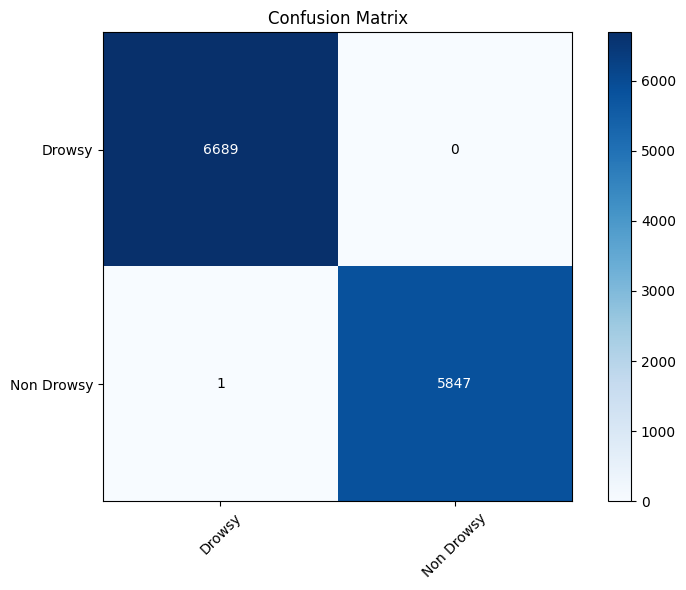

In [36]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=unique_classes)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(unique_classes, class_labels, rotation=45)
plt.yticks(unique_classes, class_labels)
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()


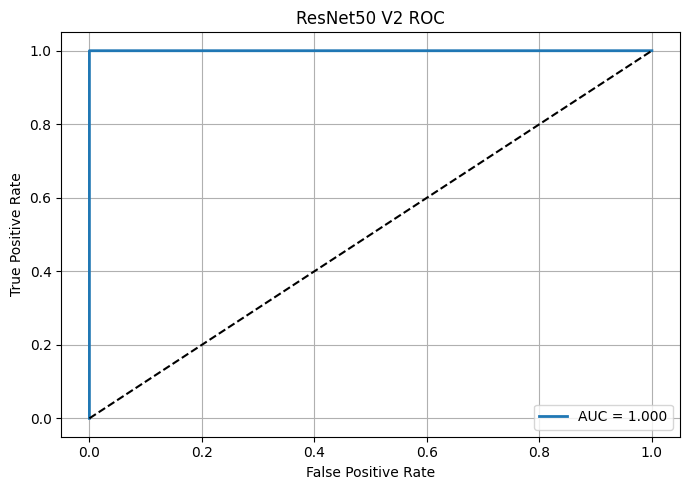

In [37]:

y_scores = y_probs[:, 1]  

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 V2 ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# Xception

In [38]:

# --- Xception model setup ---
model = timm.create_model("xception", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)




In [39]:
# --- Train the model ---
train_model(model, optimizer, scheduler, "Xception")


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:16<00:00,  6.69it/s]


Epoch 1/10 | Train Acc: 0.9945 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:17<00:00,  6.67it/s]


Epoch 2/10 | Train Acc: 0.9999 | Val Acc: 0.9999


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:17<00:00,  6.67it/s]


...

Epoch 8/10 | Train Acc: 1.0000 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:17<00:00,  6.64it/s]


Epoch 9/10 | Train Acc: 1.0000 | Val Acc: 1.0000


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:17<00:00,  6.67it/s]


Epoch 10/10 | Train Acc: 1.0000 | Val Acc: 1.0000


In [40]:

# --- Save the trained model ---
torch.save(model.state_dict(), os.path.join(OUT_DIR, "xception_final.pth"))


In [41]:

# --- Evaluation ---
model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Xception test"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_probs = np.vstack(all_probs)
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# --- Metrics ---
xception_acc = accuracy_score(y_true, y_pred)
xception_prec, xception_rec, xception_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)



Xception test: 100%|██████████████████████████████████████████████████████████████████████████████| 392/392 [00:53<00:00,  7.30it/s]


In [42]:
storeResults('Xception', xception_acc, xception_prec, xception_rec, xception_f1)


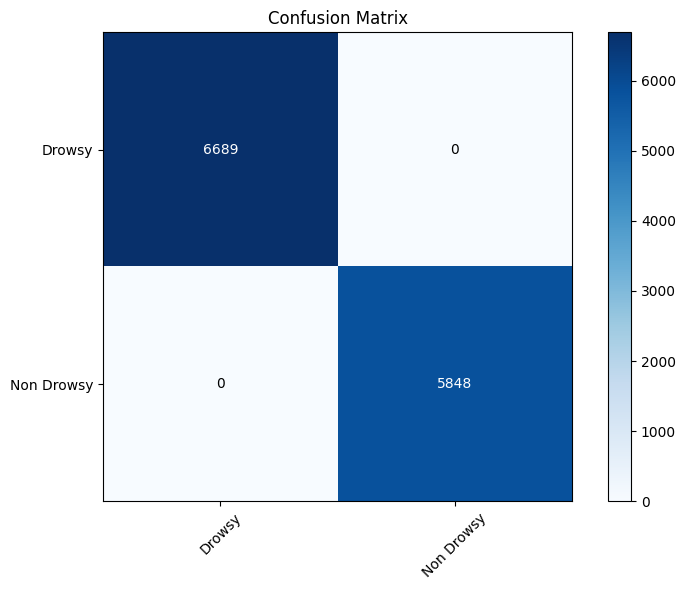

In [43]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=unique_classes)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(unique_classes, class_labels, rotation=45)
plt.yticks(unique_classes, class_labels)
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()



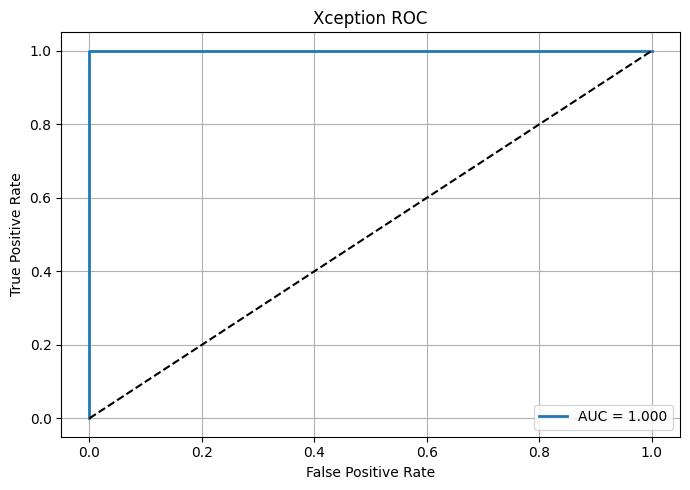

In [44]:
# --- ROC Curve (binary classification) ---
y_scores = y_probs[:, 1]  # positive class

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Xception ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# ConvNeXt-Tiny

In [45]:


model = timm.create_model("convnext_tiny", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)





In [46]:
# --- Train the model ---
train_model(model, optimizer, scheduler, "ConvNeXt-Tiny")



100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:52<00:00,  5.30it/s]


Epoch 1/10 | Train Acc: 0.9790 | Val Acc: 0.9997


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:53<00:00,  5.26it/s]


Epoch 2/10 | Train Acc: 0.9972 | Val Acc: 0.9985


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:53<00:00,  5.26it/s]


...

Epoch 8/10 | Train Acc: 1.0000 | Val Acc: 0.9998


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:53<00:00,  5.28it/s]


Epoch 9/10 | Train Acc: 1.0000 | Val Acc: 0.9998


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 915/915 [02:53<00:00,  5.28it/s]


Epoch 10/10 | Train Acc: 1.0000 | Val Acc: 0.9998


In [47]:
# --- Save the trained model ---
torch.save(model.state_dict(), os.path.join(OUT_DIR, "convnext_tiny_final.pth"))


In [48]:
# --- Evaluation ---
model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="ConvNeXt-Tiny test"):
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

y_probs = np.vstack(all_probs)
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# --- Metrics ---
convnext_acc = accuracy_score(y_true, y_pred)
convnext_prec, convnext_rec, convnext_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)



ConvNeXt-Tiny test: 100%|█████████████████████████████████████████████████████████████████████████| 392/392 [00:53<00:00,  7.30it/s]


In [49]:
storeResults('ConvNeXt-Tiny', convnext_acc, convnext_prec, convnext_rec, convnext_f1)


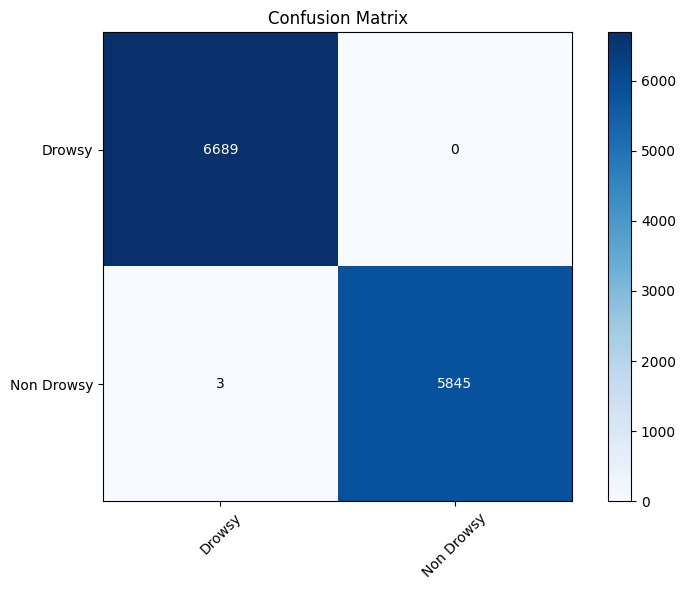

In [50]:

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred, labels=unique_classes)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(unique_classes, class_labels, rotation=45)
plt.yticks(unique_classes, class_labels)
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()


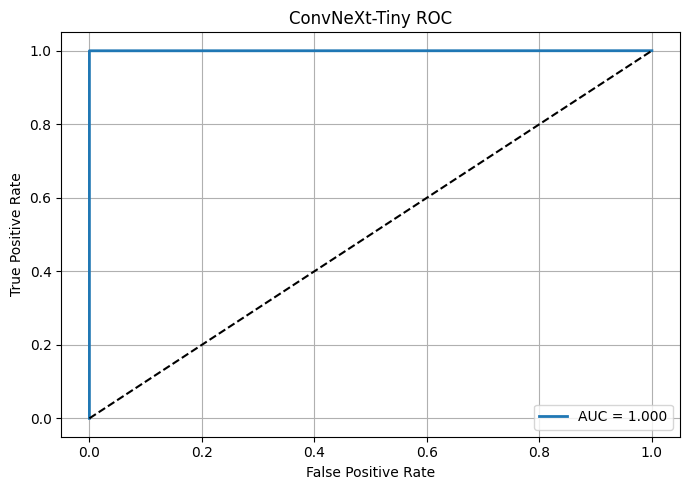

In [51]:
# --- ROC Curve (binary classification) ---
y_scores = y_probs[:, 1]  # positive class

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ConvNeXt-Tiny ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# Comparison

In [52]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score
                        
                      })

In [53]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,VGG19,0.99992,0.99993,0.99991,0.99992
1,VGG16,1.00000,1.00000,1.00000,1.00000
2,InceptionV3,1.00000,1.00000,1.00000,1.00000
3,ResNet50 V2,0.99992,0.99993,0.99991,0.99992
4,Xception,1.00000,1.00000,1.00000,1.00000
5,ConvNeXt-Tiny,0.99976,0.99978,0.99974,0.99976


# Graph

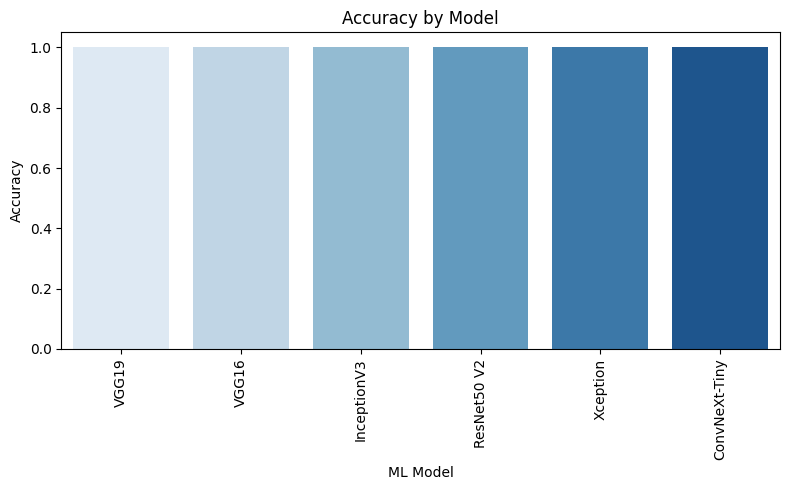

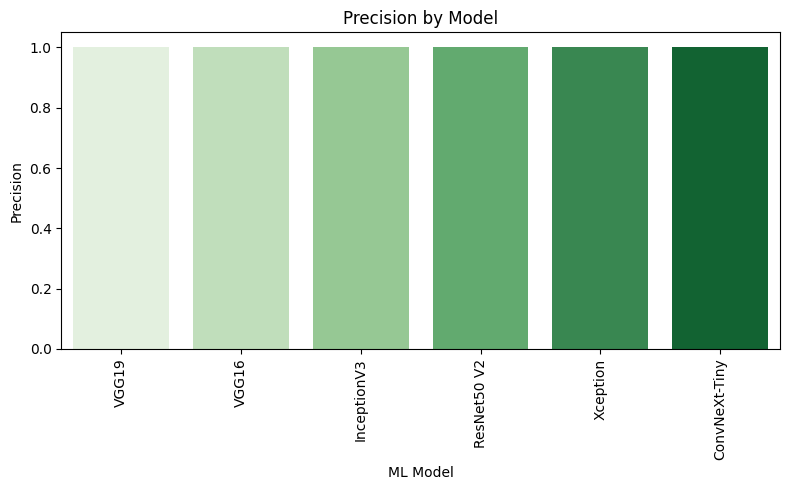

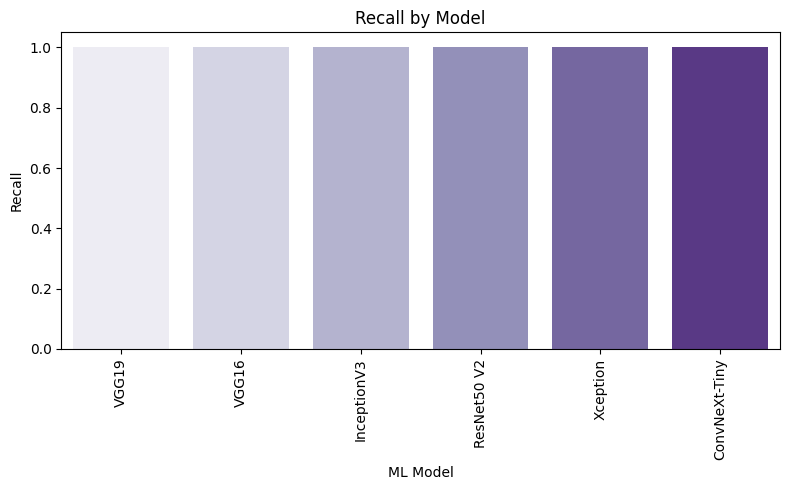

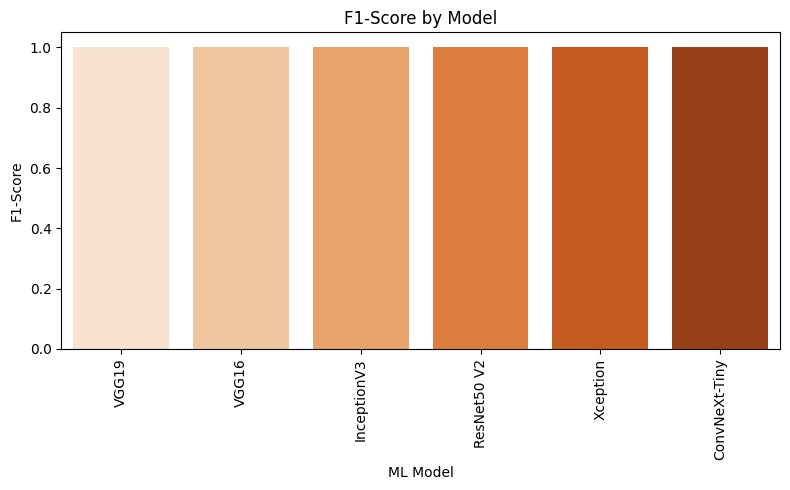

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

palettes = {
    'Accuracy': 'Blues',
    'Precision': 'Greens',
    'Recall': 'Purples',
    'F1-Score': 'Oranges'
}

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=result, x='ML Model', y=metric, palette=palettes[metric])
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()